# Conditional edges

In [1]:
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import END, START, StateGraph

In [2]:
# Helper
def visualize_graph(graph):
    from IPython.display import Image, display
    try:
        display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
    except Exception:
        # This requires some extra dependencies and is optional
        pass

In [3]:
def add(left, right):
    return left + right


class State(TypedDict):
    total: Annotated[int, add]

In [11]:
builder = StateGraph(State)
builder.add_node("add_one", lambda x: {"total": 1})
builder.add_node("plus_10", lambda x: {"total": x["total"] + 10})
builder.add_node("minus_10", lambda x: {"total": x["total"] - 10})
builder.add_edge(START, "add_one")


def route(state: State) -> Literal["plus_10", "minus_10"]:
    if state["total"] < 5:
        return "plus_10"
    else:
        return "minus_10"


builder.add_conditional_edges("add_one", route)
builder.add_edge("plus_10", END)
builder.add_edge("minus_10", END)

graph = builder.compile()

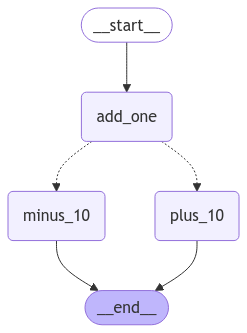

In [12]:
visualize_graph(graph)

In [10]:
graph.invoke({"total": 12})

#Flow
#0. 'thread_id'가 변경됨. state값 없음
#1  invoke -> add_one:{'total': add(기존 total값:0),{invoke total:12)}) -> 'total'=0+12 = 12}
#2. add_one -> route:conditional edge{'total': add(기존 total값:12),{현재 total:1)}) -> 'total'=12+1 = 13})
#3. route:conditional edge(state['total']=13 -> minus_10 node)
#4. add_one -> minus_10:{'total': add(기존 total값:13),{현재 total:13-10=3)}) -> 'total'=13+3 = 16}

{'total': 16}

In [15]:
graph.invoke({"total": 10})

#Flow
#0. 'thread_id'가 변경됨. state값 없음
#1  invoke -> add_one:{'total': add(기존 total값:0),{invoke total:10)}) -> 'total'=0+10 = 10}
#2. add_one -> route:conditional edge{'total': add(기존 total값:10),{현재 total:1)}) -> 'total'=10+1 = 11})
#3. route:conditional edge(state['total']=11 -> minus_10 node)
#4. add_one -> minus_10:{'total': add(기존 total값:11),{현재 total:11-10=1)}) -> 'total'=11+1 = 12}

{'total': 12}

In [17]:
graph.invoke({"total": 3})

#Flow
#0. 'thread_id'가 변경됨. state값 없음
#1  invoke -> add_one:{'total': add(기존 total값:0),{invoke total:3)}) -> 'total'=0+3 = 3}
#2. add_one -> route:conditional edge{'total': add(기존 total값:3),{현재 total:1)}) -> 'total'=3+1 = 4})
#3. route:conditional edge(state['total']=4 -> plus_10 node)
#4. add_one -> plus_10:{'total': add(기존 total값:4),{현재 total:4+10=14)}) -> 'total'=4+14 = 18}

{'total': 18}

In [ ]:
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import END, START, StateGraph

In [24]:
#1. State 정의하기
class State(TypedDict):
    name : str
    total: Annotated[int, add]

#2. Node 정의하기
def Node1(state):
    name = state['name']*2
    total = 1
    return {'name':name,'total':total}

def Plus10(state):
    return {'total' : state['total']+10}

def Minus10(state):
    return {'total' : state['total']-10}

#3. reducer 함수 정의하기 
def add(left, right):
    return left + right

#4. builder 선언하기
builder = StateGraph(State)

#5. node 선언하기
builder.add_node("node1",Node1)
builder.add_node("plus_10",Plus10)
builder.add_node("minus_10",Minus10)

#6. conditional edge 정의하기
def route(state: State) -> Literal["plus_10", "minus_10"]:
    if state["total"] < 5:
        return "plus_10"
    else:
        return "minus_10"

#7. edge 선언하기
builder.add_edge(START,'node1')
builder.add_conditional_edges('node1',route)
builder.add_edge('plus_10',END)
builder.add_edge('minus_10',END)

#8. graph compile하기
graph = builder.compile()

#9. graphe invoke하기
graph.invoke({'name':'최재일','total':10})

{'name': '최재일최재일', 'total': 12}

In [27]:
#9. graphe invoke하기
graph.invoke({'name':'최재일','total':10})

#Flow
#0. 'thread_id'가 변경됨. state값 없음
#1  invoke -> add_node:{{'name':'최재일','total': add(기존 total값:0),{invoke total:10)}) -> 'total'=0+10 = 10}
#2. add_one -> route:conditional edge{{'name':'최재일최재일','total': add(기존 total값:10),{현재 total:1)}) -> 'total'=10+1 = 11})
#3. route:conditional edge(state['total']=11 -> minus_10 node)
#4. add_one -> minus_10:{{'name':'최재일최재일','total': add(기존 total값:11),{현재 total:11-10=1)}) -> 'total'=11+1 = 12}

{'name': '최재일최재일', 'total': 12}

In [29]:
#9. graphe invoke하기
graph.invoke({'name':'최재일','total':2})

#Flow
#0. 'thread_id'가 변경됨. state값 없음
#1  invoke -> add_node:{{'name':'최재일','total': add(기존 total값:0),{invoke total:0)}) -> 'total'=0+2 = 2}
#2. add_one -> route:conditional edge{{'name':'최재일최재일','total': add(기존 total값:2),{현재 total:1)}) -> 'total'=2+1 = 3})
#3. route:conditional edge(state['total']=3 -> plus_10 node)
#4. add_one -> plus_10:{{'name':'최재일최재일','total': add(기존 total값:3),{현재 total:3+10=13)}) -> 'total'=3+13 = 16}

{'name': '최재일최재일', 'total': 16}